Generalized Additive Models:

Contributions: 
1. https://web.stanford.edu/class/stats202/notes/Nonlinear/GAM.html
2. https://academic.oup.com/jrsssc/article/64/1/139/7067572#397191485
3. https://medium.com/just-another-data-scientist/building-interpretable-models-with-generalized-additive-models-in-python-c4404eaf5515
4. https://ecogambler.netlify.app/blog/autocorrelated-gams/
5. https://www.geeksforgeeks.org/artificial-intelligence/generalized-additive-model-in-python/

In [43]:
# Import libraries:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pygam import LogisticGAM, s, l
from scipy.stats import gaussian_kde
from sklearn.metrics import accuracy_score, log_loss
from itertools import combinations
from sklearn.model_selection import ParameterGrid
import warnings
from pygam.utils import check_array
from sklearn.preprocessing import StandardScaler
import os

# ============================================
# Imports
# ============================================
from pygam import LogisticGAM, s
from itertools import combinations
from sklearn.model_selection import ParameterGrid, BaseCrossValidator
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import (
    roc_auc_score, classification_report, accuracy_score,
    f1_score, recall_score, precision_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [44]:
# Data import and pre-processing:

# Import data:
# run script from the data_input file
#os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')
os.chdir('C:/Users/ccwis/OneDrive/Documents/1. MEng - Data Science/Project/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Value_vs_Quality_trend']]    
df_factor = df_factor.set_index('Date')

df = pd.read_csv("lagged_data.csv", parse_dates=['Date'])
df = df.set_index('Date')


data = pd.concat([df,df_factor], axis=1, join='inner')
data = data.ffill()

print(data)

            VolTermStructPC1  VolTermStructPC2  MichgnConcIndx  \
Date                                                             
2007-06-18        -25.971465          9.547910            87.1   
2007-06-25        -26.283643          9.787659            87.1   
2007-07-02        -26.283553          9.942312            88.3   
2007-07-09        -28.132090          9.679810            88.3   
2007-07-16        -27.003497         10.308379            88.3   
...                      ...               ...             ...   
2025-03-03         39.101360         -6.676525            71.7   
2025-03-10         36.115275         -7.968991            71.7   
2025-03-17         35.492793         -8.161898            71.7   
2025-03-24         39.950630         -6.962702            71.7   
2025-03-31         44.421245         -5.261720            64.7   

            RandPPP_Factor_Inst_TS_ST  BCMPEBLS.Index  PPP.ZA.Index_QS  \
Date                                                               

In [45]:

# ============================================
# GAM Formula Builder
# ============================================
def build_gam_formula(feature_variables):
    """Build smooth spline terms for all features."""
    gam_formula = s(0)
    for i in range(1, len(feature_variables)):
        gam_formula += s(i)
    return gam_formula


In [46]:
# ============================================
# Combinatorial Purged CV Splitter
# ============================================
CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 12
FINAL_TEST_POINTS = 156  # ~3 years of unseen data

class CombinatorialPurgedCV(BaseCrossValidator):
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)
        fold_bounds = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_bounds[-1] = (fold_bounds[-1][0], n_samples)

        for test_folds in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)
            for f in test_folds:
                s_, e_ = fold_bounds[f]
                test_mask[s_:e_] = True

            train_mask = ~test_mask
            for f in test_folds:
                s_, e_ = fold_bounds[f]
                train_mask[max(0, s_ - self.purge_gap): s_] = False
                train_mask[e_: min(n_samples, e_ + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]

    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)


In [47]:
import hashlib

def window_signature(X):
    """
    Create a stable, compact signature for a rolling window
    based on its mean and std across features.
    """
    stats = np.concatenate([X.mean(axis=0), X.std(axis=0)])
    stats_bytes = stats.tobytes()
    return hashlib.sha1(stats_bytes).hexdigest()

In [48]:
import warnings

def tune_hyperparameters(X, y, feature_variables):
    cv = CombinatorialPurgedCV()
    gam_formula = build_gam_formula(feature_variables)

    param_grid = {
        "lam": [1, 10, 25, 100],
        "n_splines": [5, 7, 10],
        "max_iter": [200,500,1000],
        "fit_intercept": [True],
    }

    best_score, best_params = -np.inf, None
    results = []

    grid = list(ParameterGrid(param_grid))
    print(f"Testing {len(grid)} parameter combinations...")

    for params in grid:
        fold_scores = []

        for train_idx, test_idx in cv.split(X, y):

            # Skip folds with single-class y (ROC undefined)
            if len(np.unique(y[test_idx])) < 2 or len(np.unique(y[train_idx])) < 2:
                continue

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")

                    gam = LogisticGAM(
                        gam_formula,
                        **params
                    ).fit(X[train_idx], y[train_idx])

                y_prob = gam.predict_proba(X[test_idx])
                score = roc_auc_score(y[test_idx], y_prob)
                fold_scores.append(score)

            except Exception:
                continue

        if fold_scores:
            mean_score = float(np.mean(fold_scores))
            results.append((params, mean_score))

            if mean_score > best_score:
                best_score, best_params = mean_score, params
                print(f"New best params: {best_params} (ROC AUC: {best_score:.3f})")

    results.sort(key=lambda x: x[1], reverse=True)

    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")

    if best_params is None:
        raise RuntimeError("Hyperparameter search found no valid folds. Check your labels per fold and purge gap.")

    return best_params

In [49]:
# ============================================
# Walk-Forward Validation
# ============================================
def walk_forward_validation(
    X,
    y,
    feature_variables,
    n_test,
    base_params,
    lookback=360,
    retune_every=52
):
    """
    Rolling-window GAM WFV,
    minimal configuration:
      - lookback window size
      - retune frequency
    """

    actuals, preds, probs = [], [], []

    current_params = base_params.copy()
    gam_formula = build_gam_formula(feature_variables)

    hyperparam_cache = {}

    print(f"\nRunning Rolling-Window GAM WFV...")
    print(f"Lookback = {lookback}")
    print(f"Retune every = {retune_every}")
    print(f"Total test points = {n_test}")

    from sklearn.preprocessing import StandardScaler

    for i in tqdm(range(n_test)):

        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        # ===== slice rolling window =====
        start = max(0, train_size - lookback)
        X_train = X[start:train_size]
        y_train = y[start:train_size]

        X_test  = X[train_size:train_size+1]
        y_test  = y[train_size:train_size+1]

        # ===== scaling =====
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        # ===== retuning =====
        if retune_every and i > 0 and i % retune_every == 0:

            sig = window_signature(X_train)

            if sig in hyperparam_cache:
                current_params = hyperparam_cache[sig]
            else:
                current_params = tune_hyperparameters(X_train, y_train, feature_variables)
                hyperparam_cache[sig] = current_params

        # ===== model training =====
        gam = LogisticGAM(gam_formula, **current_params).fit(X_train, y_train)

        # ===== predict =====
        y_prob = gam.predict_proba(X_test)
        y_pred = (y_prob >= 0.5).astype(int)

        actuals.append(y_test[0])
        preds.append(y_pred[0])
        probs.append(y_prob[0])

    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, preds))

    return (
        np.array(actuals),
        np.array(preds),
        np.array(probs)
    )



In [50]:
# ============================================
# Results Visualization
# ============================================
def display_walkforward_results(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    print(f"Accuracy : {acc:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)

        y_proba_clipped = np.clip(y_proba, 1e-12, 1 - 1e-12)
        ll = log_loss(y_true, y_proba_clipped)

        print(f"ROC AUC  : {auc:.3f}")
        print(f"PR  AUC  : {pr_auc:.3f}")
        print(f"Log Loss : {ll:.3f}")

    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="True", marker="o")
    plt.plot(y_pred, label="Predicted", marker="x")
    plt.plot(y_proba,label="Probability",linestyle='--', alpha=0.5)
    plt.title("Walk-forward Predictions vs True Values")
    plt.legend()
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
        plt.plot([0,1],[0,1], '--', color='gray')
        plt.legend()
        plt.show()

        precs, recs, _ = precision_recall_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(recs, precs, label=f"PR (AP={pr_auc:.3f})", color="purple")
        plt.legend()
        plt.show()

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()



=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 36 parameter combinations...
New best params: {'fit_intercept': True, 'lam': 1, 'max_iter': 200, 'n_splines': 5} (ROC AUC: 0.536)

=== Top 5 Parameter Combinations ===
Score: 0.536 | Params: {'fit_intercept': True, 'lam': 1, 'max_iter': 200, 'n_splines': 5}
Score: 0.536 | Params: {'fit_intercept': True, 'lam': 1, 'max_iter': 500, 'n_splines': 5}
Score: 0.536 | Params: {'fit_intercept': True, 'lam': 1, 'max_iter': 1000, 'n_splines': 5}
Score: 0.536 | Params: {'fit_intercept': True, 'lam': 25, 'max_iter': 200, 'n_splines': 10}
Score: 0.536 | Params: {'fit_intercept': True, 'lam': 25, 'max_iter': 500, 'n_splines': 10}

=== PHASE 2: FINAL EVALUATION ===

Running Rolling-Window GAM WFV...
Lookback = 360
Retune every = 52
Total test points = 156


 33%|███▎      | 52/156 [00:13<00:30,  3.43it/s]

Testing 36 parameter combinations...
New best params: {'fit_intercept': True, 'lam': 1, 'max_iter': 200, 'n_splines': 5} (ROC AUC: 0.650)
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
New best params: {'fit_intercept': True, 'lam': 10, 'max_iter': 200, 'n_splines': 5} (ROC AUC: 0.658)
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
New best params: {'fit_intercept': True, 'lam': 100, 'max_iter': 200, 'n_splines': 5} (ROC AUC: 0.658)
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not con

 67%|██████▋   | 104/156 [28:42<00:11,  4.36it/s]   

Testing 36 parameter combinations...
New best params: {'fit_intercept': True, 'lam': 1, 'max_iter': 200, 'n_splines': 5} (ROC AUC: 0.548)
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
New best params: {'fit_intercept': True, 'lam': 10, 'max_iter': 200, 'n_splines': 5} (ROC AUC: 0.548)
did not converge
did not converge
did not converge
New best params: {'fit_intercept': True, 'lam': 10, 'max_iter': 200, 'n_splines': 7} (ROC AUC: 0.594)
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not conv

100%|██████████| 156/156 [1:02:46<00:00, 24.14s/it]   



=== Final Evaluation Results ===
              precision    recall  f1-score   support

         0.0       0.65      0.69      0.67        89
         1.0       0.55      0.51      0.53        67

    accuracy                           0.61       156
   macro avg       0.60      0.60      0.60       156
weighted avg       0.61      0.61      0.61       156


=== ADAPTIVE PARAMS RESULTS ===
Accuracy : 0.609
F1 Score : 0.527
Recall   : 0.507
Precision: 0.548
ROC AUC  : 0.635
PR  AUC  : 0.623
Log Loss : 0.916


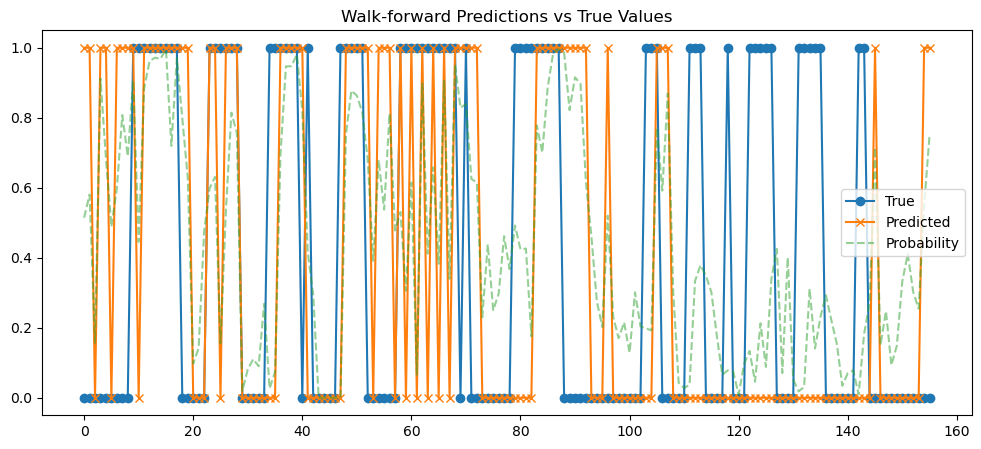

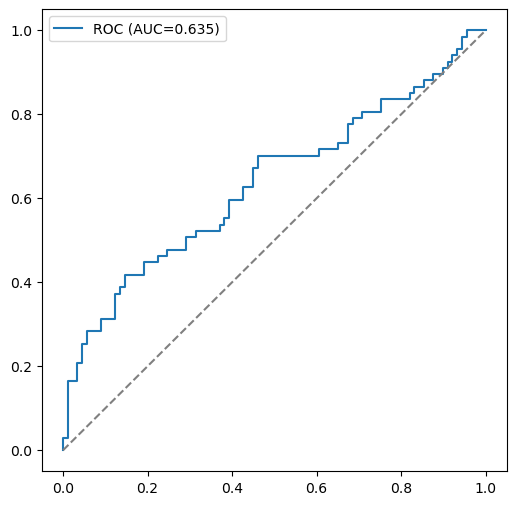

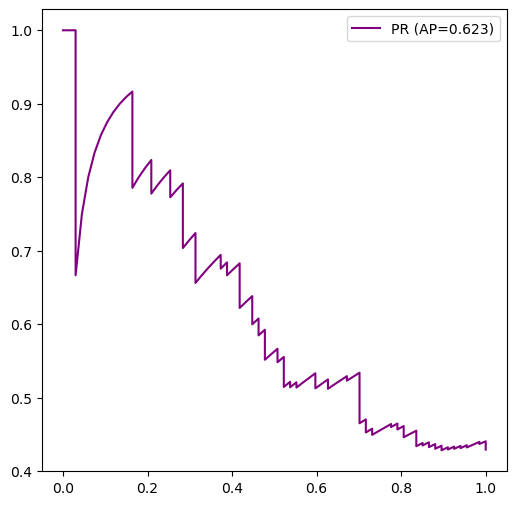

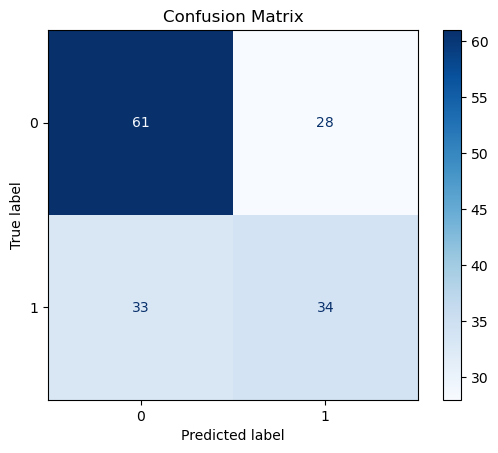

In [51]:
# ============================================
# Run model
# ============================================
def main():
    # === Data Preparation ===
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_variables = data.columns[:-1].tolist()
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)

    # === Phase 1: Hyperparameter tuning (on full sample) ===
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X, y, feature_variables)

    # === Phase 2: Final Evaluation ===
    print("\n=== PHASE 2: FINAL EVALUATION ===")

    # Adaptive params, rolling window
    actuals_adapt, preds_adapt, probs_adapt = walk_forward_validation(
        X,
        y,
        feature_variables,
        FINAL_TEST_POINTS,
        best_params,
        lookback=360,
        retune_every=52
    )

    # === Phase 3: Visualization ===


    print("\n=== ADAPTIVE PARAMS RESULTS ===")
    display_walkforward_results(actuals_adapt, preds_adapt, probs_adapt)

    return {
    "best_params": best_params,
    "adaptive": (actuals_adapt, preds_adapt, probs_adapt),
    "X": X,
    "y": y,
    "feature_variables": feature_variables
}



if __name__ == "__main__":
    results = main()

In [52]:
#results = main()

#results_gam = results["best_params"]
#print(results_gam)

In [53]:
import numpy as np
import pandas as pd
import shap
from pygam import LogisticGAM

X = results["X"]
y = results["y"]
feature_names = results["feature_variables"]

X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
train_end = len(X) - FINAL_TEST_POINTS
X_train = X[:train_end]
y_train = y[:train_end]

final_gam = LogisticGAM(
    build_gam_formula(feature_names),
    **results["best_params"]   # {'fit_intercept': True, 'lam':100, 'max_iter':500, 'n_splines':5}
).fit(X_train, y_train)

def gam_predict_log_odds(X_in):
    # Predict probability
    p = final_gam.predict_proba(X_in)
    p = np.asarray(p).astype(float)
    # Clip for numerical stability then logit
    eps = 1e-6
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))  # log-odds

# Use SHAP explainer on log-odds output
# Using X_train as background keeps baseline consistent with training distribution
explainer = shap.Explainer(gam_predict_log_odds, X_train)
shap_values = explainer(X_train)

importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print("\n=== GAM SHAP Global Importance (Mean |SHAP|, log-odds) ===")
print(importance.head(20))



PermutationExplainer explainer: 774it [16:54,  1.32s/it]                         


=== GAM SHAP Global Importance (Mean |SHAP|, log-odds) ===
relvol_momentum_vs_quality_12       1.791474
relvol_value_vs_quality_12          1.769404
GlobalPropertyVol12                 0.834094
RandPPP_Factor_Inst_TS_ST           0.659005
SA_NB_Slope                         0.553872
zrel_momentum_vs_quality_12         0.449483
USDZARV1Y.Curncy_QS                 0.435641
USDZAR_EntDyn                       0.432962
TOP40.Index.Price.to.Ebitda_Diff    0.420131
volratio_momentum_value_12          0.366062
corr_momentum_quality_12            0.360515
MXWD.Index.PE.Ratio_QS              0.340285
corr_value_quality_12               0.328025
USDZARV1M.Curncy_QS                 0.316392
MichgnConcIndx                      0.285791
GenComIndexPC1_QS                   0.236045
zrel_momentum_vs_value_12           0.193465
JALSH_Fundamental_PC1               0.185337
VolTermStructPC1                    0.179464
ZAR18M.Curncy_QS                    0.177093
dtype: float64


In [54]:
shap_vals = importance.head(20)
shap_vals.to_csv("gam_shap.csv", index=True)


C:\Users\ccwis\AppData\Local\Temp\ipykernel_18000\3449520824.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type="dot")


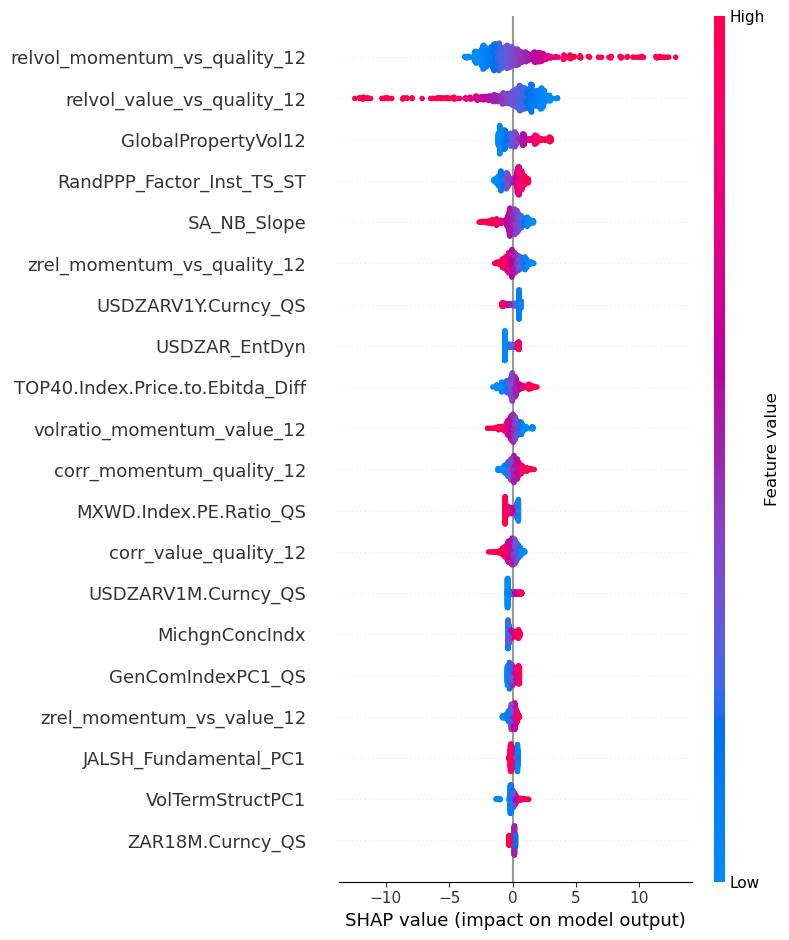

In [56]:

shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type="dot")
